# Hướng dẫn cài đặt thư mục và chạy notebook trên GPU L4 22.5GB

Notebook này cài đặt **Transformer Base 2017 encoder-decoder from scratch** cho bài toán tóm tắt văn bản tiếng Việt.  
Notebook **không dùng `nn.Transformer`**, không dùng mô hình pretrained để huấn luyện; toàn bộ embedding, positional encoding, multi-head attention, encoder, decoder, feed-forward, residual connection và learning-rate schedule được cài đặt thủ công bằng PyTorch.

Bản này được cấu hình lại để chạy ổn định hơn trên **GPU NVIDIA L4 khoảng 22.5GB VRAM**. Kiến trúc Transformer vẫn giữ đúng bản gốc 2017; phần được giảm chủ yếu là **batch size** và **độ dài article tối đa** để tránh CUDA out of memory.

## 1. Cấu trúc thư mục khuyến nghị trên Colab

Tạo hoặc để notebook tự tạo thư mục:

```text
/content/transformer_2017_vi_summarization/
├── data/
│   ├── train.parquet          # Bắt buộc: tập huấn luyện
│   ├── val.parquet            # Bắt buộc: tập validation riêng
│   └── test.parquet           # Chưa cần ngay; dùng vào ngày thầy cung cấp tập test
└── outputs/
    ├── checkpoints/
    │   ├── transformer_2017_best.pt
    │   └── transformer_2017_last.pt
    ├── training_history.csv
    ├── loss_curve.png
    ├── val_predictions.csv
    ├── val_metrics.json
    ├── test_predictions.csv
    └── test_metrics.json      # Chỉ có nếu test.parquet chứa cột summary
```

Notebook cũng tự tìm dữ liệu trong một số vị trí phổ biến như:

```text
/content/transformer_2017_vi_summarization/data/
/content/data/
/content/
/mnt/data/
```

## 2. Định dạng dữ liệu

`train.parquet` và `val.parquet` cần có ít nhất 2 cột:

```text
article    # Văn bản đầu vào
summary    # Tóm tắt tham chiếu
```

`test.parquet` ngày cuối có thể rơi vào 2 trường hợp:

```text
Trường hợp 1: có article và summary  → notebook sinh prediction + tính ROUGE/BERTScore.
Trường hợp 2: chỉ có article         → notebook chỉ sinh prediction để nộp/chấm ngoài.
```

## 3. Cách chạy khi đang train/validation trên L4

1. Upload `train.parquet` và `val.parquet` vào thư mục `data/`.
2. Chọn GPU L4: `Runtime → Change runtime type → GPU`. Nếu Colab cho chọn loại GPU, chọn **L4**.
3. Chạy: `Runtime → Restart session and run all`.
4. Theo dõi `train_loss`, `valid_loss` và file `loss_curve.png`.
5. Sau training, notebook tự load checkpoint tốt nhất để đánh giá validation.

Nếu bị `CUDA out of memory`, giảm theo thứ tự sau trong cell cấu hình:

```python
TRAIN_BATCH_SIZE = 4
VALID_BATCH_SIZE = 8
GRADIENT_ACCUMULATION_STEPS = 16
```

Nếu vẫn lỗi, giảm tiếp:

```python
SRC_SEQ_LEN = 256
TGT_SEQ_LEN = 96
```

## 4. Cách chạy khi nhận được `test.parquet` vào ngày cuối

1. Upload `test.parquet` vào:

```text
/content/transformer_2017_vi_summarization/data/test.parquet
```

2. Mở cell cấu hình và đổi:

```python
RUN_TEST_EVALUATION = True
```

3. Nếu runtime vẫn còn model sau khi train xong, chỉ cần chạy các cell từ phần **18. Đánh giá trên tập test cuối kỳ** trở xuống.
4. Nếu runtime đã bị reset, chạy lại notebook từ đầu; notebook sẽ train/lưu checkpoint, rồi phần test sẽ tự load `transformer_2017_best.pt` để sinh kết quả.
5. Kết quả test sẽ được lưu tại:

```text
outputs/test_predictions.csv
outputs/test_metrics.json  # chỉ có nếu test.parquet chứa summary
```

## 5. Các điểm bám sát Transformer 2017

- Residual connection dùng dạng **post-norm**: `LayerNorm(x + Dropout(Sublayer(x)))`.
- Feed Forward dùng `Linear → ReLU → Dropout → Linear`.
- Positional encoding là sinusoidal positional encoding.
- Optimizer dùng Adam với `betas=(0.9, 0.98)`, `eps=1e-9`.
- Learning-rate schedule dùng công thức warmup của paper Transformer.
- Training dùng label smoothing `0.1`.
- Không dùng `nn.Transformer`, không dùng pretrained model để train.

## 6. Lưu ý riêng cho L4

Cấu hình mặc định của bản này giữ **Transformer Base 2017** nhưng dùng batch nhỏ hơn A100:

```text
D_MODEL = 512
N_LAYERS = 6
N_HEADS = 8
D_FF = 2048
SRC_SEQ_LEN = 384
TGT_SEQ_LEN = 128
TRAIN_BATCH_SIZE = 8
VALID_BATCH_SIZE = 16
GRADIENT_ACCUMULATION_STEPS = 8
```

Nhờ gradient accumulation, batch hiệu dụng xấp xỉ:

```text
8 × 8 = 64 samples / optimizer step
```

Cách này tiết kiệm VRAM nhưng vẫn giữ batch hiệu dụng gần cấu hình A100.


# Transformer 2017 from scratch cho tóm tắt văn bản tiếng Việt

Notebook này tự cài đặt mô hình Transformer encoder-decoder bằng PyTorch, không dùng `nn.Transformer`.

Mục tiêu:

1. Cài đặt đúng kiến trúc Transformer gốc năm 2017.
2. Gắn dữ liệu tóm tắt tiếng Việt dạng `article → summary`.
3. Huấn luyện trên GPU L4 22.5GB với batch nhỏ, BF16/TF32 nếu khả dụng và gradient accumulation phù hợp.
4. Lưu lịch sử loss, checkpoint và vẽ biểu đồ loss.

Các thành phần bám sát Transformer 2017:

- embedding nhân `sqrt(d_model)`;
- sinusoidal positional encoding;
- scaled dot-product multi-head attention;
- encoder self-attention;
- decoder masked self-attention;
- decoder cross-attention;
- feed-forward `Linear → ReLU → Dropout → Linear`;
- residual connection + dropout + LayerNorm theo dạng **post-norm**;
- Xavier initialization;
- Adam + warmup learning-rate schedule;
- label smoothing.


# 0. Import thư viện, cố định seed và thiết lập thiết bị

Cell này import thư viện cần thiết, cố định random seed và chọn thiết bị chạy.

Nếu có GPU L4 hoặc GPU NVIDIA hiện đại, notebook bật thêm:

- **TF32** để tăng tốc phép nhân ma trận trên GPU hỗ trợ Tensor Cores;
- **BF16 autocast** nếu GPU/PyTorch hỗ trợ, giúp giảm bộ nhớ khi train.

Các tối ưu BF16/TF32 chỉ thay đổi cách tính toán số học trên GPU, không thay đổi cấu trúc Transformer 2017.


In [1]:
import math
import os
import random
import time
from contextlib import nullcontext
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Tối ưu cho GPU NVIDIA hiện đại như L4/A100.
# TF32 tăng tốc matmul/convolution nhưng vẫn giữ mô hình và công thức Transformer không đổi.
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print(f'Torch: {torch.__version__}')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    total_mem_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'GPU memory: {total_mem_gb:.2f} GB')


Torch: 2.11.0+cu128
Device: cuda
GPU: NVIDIA L4
GPU memory: 22.03 GB


# 1. Các khối nền tảng của Transformer 2017

Cell này khai báo các thành phần dùng chung trong mô hình:

- `InputEmbedding`: ánh xạ token ID thành embedding và nhân với `sqrt(d_model)`.
- `PositionalEncoding`: sinusoidal positional encoding cố định như paper 2017.
- `LayerNormalization`: tự cài LayerNorm với tham số học được theo từng chiều `d_model`.
- `ResidualConnection`: Add & Norm **post-norm** đúng công thức Transformer 2017:

```python
LayerNorm(x + Dropout(Sublayer(x)))
```

- `create_src_mask`: che padding ở encoder.
- `create_tgt_mask`: che padding và token tương lai ở decoder.


In [2]:
class InputEmbedding(nn.Module):
    def __init__(self, d_model: int, vocab_size: int):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)

    def forward(self, x):
        # Paper 2017 scale embedding bằng sqrt(d_model) trước khi cộng positional encoding.
        return self.embedding(x) * math.sqrt(self.d_model)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int, dropout: float):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # shape: (1, max_len, d_model)

        # Positional encoding là hằng số, không phải tham số học được.
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :].requires_grad_(False)
        return self.dropout(x)


class LayerNormalization(nn.Module):
    def __init__(self, features: int, epsilon: float = 1e-6) -> None:
        super().__init__()
        self.epsilon = epsilon
        self.alpha = nn.Parameter(torch.ones(features))
        self.bias = nn.Parameter(torch.zeros(features))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        return self.alpha * (x - mean) / torch.sqrt(var + self.epsilon) + self.bias


class ResidualConnection(nn.Module):
    def __init__(self, d_model: int, dropout: float) -> None:
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.norm = LayerNormalization(d_model)

    def forward(self, x, sublayer):
        # Transformer 2017 dùng post-norm:
        # LayerNorm(x + Dropout(Sublayer(x)))
        return self.norm(x + self.dropout(sublayer(x)))


def causal_mask(size: int) -> torch.Tensor:
    # True ở các vị trí được phép attention, False ở token tương lai.
    mask = torch.triu(torch.ones(1, size, size, dtype=torch.bool), diagonal=1)
    return ~mask


def create_src_mask(src: torch.Tensor, pad_idx: int = 0) -> torch.Tensor:
    # shape: (batch, 1, 1, src_len), broadcast được sang attention score.
    return (src != pad_idx).unsqueeze(1).unsqueeze(2)


def create_tgt_mask(tgt: torch.Tensor, pad_idx: int = 0) -> torch.Tensor:
    # Padding mask: decoder không attention vào <pad>.
    tgt_pad_mask = (tgt != pad_idx).unsqueeze(1).unsqueeze(2)
    # Causal mask: decoder không nhìn thấy các token tương lai.
    tgt_causal_mask = causal_mask(tgt.size(1)).type_as(tgt_pad_mask).to(tgt.device)
    return tgt_pad_mask & tgt_causal_mask


def create_masks(src: torch.Tensor, tgt: torch.Tensor, pad_idx: int = 0):
    return create_src_mask(src, pad_idx), create_tgt_mask(tgt, pad_idx)


def subsequent_mask(size: int) -> torch.Tensor:
    return causal_mask(size)


# 2. Feed Forward, Multi-Head Attention và Encoder

Cell này cài đặt các thành phần chính của encoder theo Transformer 2017:

- `FeedForwardBlock`: position-wise feed-forward network `Linear → ReLU → Dropout → Linear`.
- `MultiHeadAttentionBlock`: scaled dot-product multi-head attention chuẩn.
- `EncoderBlock`: gồm self-attention và feed-forward, mỗi sub-layer được bọc bằng Add & Norm post-norm.
- `Encoder`: xếp chồng `N` encoder blocks.

Không dùng các biến thể hiện đại như SwiGLU, RMSNorm, RoPE, GQA/MQA hoặc FlashAttention API.


In [3]:
class FeedForwardBlock(nn.Module):
    """Position-wise Feed Forward chuẩn Transformer 2017.

    Công thức: max(0, xW1 + b1)W2 + b2
    """
    def __init__(self, d_model: int, d_ff: int, dropout: float) -> None:
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear2(self.dropout(torch.relu(self.linear1(x))))


class MultiHeadAttentionBlock(nn.Module):
    """Multi-Head Attention tiêu chuẩn, không dùng GQA/MQA."""
    def __init__(self, d_model: int, num_head: int, dropout: float) -> None:
        super().__init__()
        self.d_model = d_model
        self.num_head = num_head
        assert d_model % num_head == 0, 'd_model must be divisible by num_head'

        self.d_k = d_model // num_head
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.attention_score = None

    @staticmethod
    def attention(query, key, value, mask, dropout: nn.Dropout):
        d_k = query.shape[-1]
        attention_score = (query @ key.transpose(-2, -1)) / math.sqrt(d_k)

        if mask is not None:
            attention_score = attention_score.masked_fill(mask == 0, -1e9)

        attention_score = attention_score.softmax(dim=-1)

        if dropout is not None:
            attention_score = dropout(attention_score)

        return attention_score @ value, attention_score

    def forward(self, q, k, v, mask):
        query = self.w_q(q)
        key = self.w_k(k)
        value = self.w_v(v)

        batch_size = query.shape[0]
        query = query.view(batch_size, -1, self.num_head, self.d_k).transpose(1, 2)
        key = key.view(batch_size, -1, self.num_head, self.d_k).transpose(1, 2)
        value = value.view(batch_size, -1, self.num_head, self.d_k).transpose(1, 2)

        x, self.attention_score = MultiHeadAttentionBlock.attention(
            query, key, value, mask, self.dropout
        )

        x = x.transpose(1, 2).contiguous().view(batch_size, -1, self.num_head * self.d_k)
        return self.w_o(x)


class EncoderBlock(nn.Module):
    def __init__(self, self_attention_block: MultiHeadAttentionBlock, feed_forward_block: FeedForwardBlock, d_model: int, dropout: float) -> None:
        super().__init__()
        self.self_attention_block = self_attention_block
        self.feed_forward_block = feed_forward_block
        self.residual_connection = nn.ModuleList([
            ResidualConnection(d_model, dropout) for _ in range(2)
        ])

    def forward(self, x, src_mask):
        x = self.residual_connection[0](x, lambda x: self.self_attention_block(x, x, x, src_mask))
        x = self.residual_connection[1](x, self.feed_forward_block)
        return x


class Encoder(nn.Module):
    def __init__(self, layers: nn.ModuleList) -> None:
        super().__init__()
        self.layers = layers

    def forward(self, x, mask):
        # Transformer 2017 không cần final LayerNorm ngoài stack,
        # vì mỗi sub-layer đã có Add & Norm dạng post-norm.
        for layer in self.layers:
            x = layer(x, mask)
        return x


# 3. Decoder, projection layer và hàm build Transformer

Cell này cài đặt decoder và hàm đóng gói mô hình:

- `DecoderBlock`: gồm masked self-attention, cross-attention và feed-forward.
- `Decoder`: xếp chồng `N` decoder blocks.
- `ProjectionLayer`: chiếu hidden state của decoder sang vocabulary và trả **logits thô**.
- `Transformer`: gom encoder, decoder, embedding, positional encoding và projection.
- `build_transformer`: khởi tạo Transformer Base theo cấu hình 2017.

Vì projection trả logits thô, training sử dụng `nn.CrossEntropyLoss`. Cách này tương đương linear + softmax khi tính loss, đúng với mô tả của paper.


In [4]:
class DecoderBlock(nn.Module):
    def __init__(self, self_attention: MultiHeadAttentionBlock, cross_attention: MultiHeadAttentionBlock, feed_forward_block: FeedForwardBlock, d_model: int, dropout: float) -> None:
        super().__init__()
        self.self_attention = self_attention
        self.cross_attention = cross_attention
        self.feed_forward_block = feed_forward_block
        self.residual_connection = nn.ModuleList([
            ResidualConnection(d_model, dropout) for _ in range(3)
        ])

    def forward(self, x, encoder_output, src_mask, tgt_mask):
        x = self.residual_connection[0](x, lambda x: self.self_attention(x, x, x, tgt_mask))
        x = self.residual_connection[1](x, lambda x: self.cross_attention(x, encoder_output, encoder_output, src_mask))
        x = self.residual_connection[2](x, self.feed_forward_block)
        return x


class Decoder(nn.Module):
    def __init__(self, layers: nn.ModuleList) -> None:
        super().__init__()
        self.layers = layers

    def forward(self, x, encoder_output, src_mask, tgt_mask):
        # Transformer 2017 không thêm final norm ngoài decoder stack.
        for layer in self.layers:
            x = layer(x, encoder_output, src_mask, tgt_mask)
        return x


class ProjectionLayer(nn.Module):
    def __init__(self, d_model: int, vocab_size: int) -> None:
        super().__init__()
        self.projection = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        # Trả logits thô. CrossEntropyLoss sẽ tự áp dụng log_softmax bên trong.
        return self.projection(x)


class Transformer(nn.Module):
    def __init__(self, encoder: Encoder, decoder: Decoder, src_embed: InputEmbedding, tgt_embed: InputEmbedding, src_pos: PositionalEncoding, tgt_pos: PositionalEncoding, projection_layer: ProjectionLayer) -> None:
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed
        self.tgt_embed = tgt_embed
        self.src_pos = src_pos
        self.tgt_pos = tgt_pos
        self.projection_layer = projection_layer

    def encode(self, src, src_mask):
        src = self.src_embed(src)
        src = self.src_pos(src)
        return self.encoder(src, src_mask)

    def decode(self, encoder_output, src_mask, tgt, tgt_mask):
        tgt = self.tgt_embed(tgt)
        tgt = self.tgt_pos(tgt)
        return self.decoder(tgt, encoder_output, src_mask, tgt_mask)

    def project(self, x):
        return self.projection_layer(x)


def build_transformer(
    src_vocab_size: int,
    tgt_vocab_size: int,
    src_seq_len: int,
    tgt_seq_len: int,
    d_model: int = 512,
    N: int = 6,
    h: int = 8,
    dropout: float = 0.1,
    d_ff: int = 2048,
    share_embeddings: bool = True,
) -> Transformer:
    src_embed = InputEmbedding(d_model, src_vocab_size)
    tgt_embed = InputEmbedding(d_model, tgt_vocab_size)

    src_pos = PositionalEncoding(d_model, src_seq_len, dropout)
    tgt_pos = PositionalEncoding(d_model, tgt_seq_len, dropout)

    encoder_blocks = []
    for _ in range(N):
        encoder_self_attention_block = MultiHeadAttentionBlock(d_model, h, dropout)
        feed_forward_block = FeedForwardBlock(d_model, d_ff, dropout)
        encoder_block = EncoderBlock(encoder_self_attention_block, feed_forward_block, d_model, dropout)
        encoder_blocks.append(encoder_block)

    decoder_blocks = []
    for _ in range(N):
        decoder_self_attention_block = MultiHeadAttentionBlock(d_model, h, dropout)
        decoder_cross_attention_block = MultiHeadAttentionBlock(d_model, h, dropout)
        feed_forward_block = FeedForwardBlock(d_model, d_ff, dropout)
        decoder_block = DecoderBlock(decoder_self_attention_block, decoder_cross_attention_block, feed_forward_block, d_model, dropout)
        decoder_blocks.append(decoder_block)

    encoder = Encoder(nn.ModuleList(encoder_blocks))
    decoder = Decoder(nn.ModuleList(decoder_blocks))
    projection_layer = ProjectionLayer(d_model, tgt_vocab_size)

    transformer = Transformer(encoder, decoder, src_embed, tgt_embed, src_pos, tgt_pos, projection_layer)

    # Xavier initialization như các implementation Transformer cổ điển.
    for p in transformer.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)

    # Paper 2017 chia sẻ embedding và pre-softmax weight khi source/target dùng chung vocabulary.
    # Với bài tóm tắt tiếng Việt, source và target dùng chung vocab nên có thể bật weight tying.
    if share_embeddings and src_vocab_size == tgt_vocab_size:
        transformer.tgt_embed.embedding.weight = transformer.src_embed.embedding.weight
        transformer.projection_layer.projection.weight = transformer.tgt_embed.embedding.weight

    return transformer


# 4. Kiểm tra nhanh forward pass bằng dữ liệu giả

Cell này tạo mô hình nhỏ và batch token ngẫu nhiên để kiểm tra luồng tensor:

- source và target token IDs;
- source mask và target causal mask;
- encoder output;
- decoder output;
- logits sau projection.

Nếu các `assert` pass, mô hình đã chạy đúng về mặt shape. Đây chưa phải training thật.


In [5]:
PAD_IDX = 0
SRC_VOCAB_SIZE = 120
TGT_VOCAB_SIZE = 120
SRC_SEQ_LEN = 12
TGT_SEQ_LEN = 10
BATCH_SIZE = 4

model = build_transformer(
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    src_seq_len=SRC_SEQ_LEN,
    tgt_seq_len=TGT_SEQ_LEN,
    d_model=64,
    N=2,
    h=4,
    dropout=0.1,
    d_ff=128,
    share_embeddings=True,
).to(device)

src = torch.randint(1, SRC_VOCAB_SIZE, (BATCH_SIZE, SRC_SEQ_LEN), device=device)
tgt_input = torch.randint(1, TGT_VOCAB_SIZE, (BATCH_SIZE, TGT_SEQ_LEN), device=device)

src[:, -2:] = PAD_IDX
tgt_input[:, -1:] = PAD_IDX

src_mask, tgt_mask = create_masks(src, tgt_input, pad_idx=PAD_IDX)

encoder_output = model.encode(src, src_mask)
decoder_output = model.decode(encoder_output, src_mask, tgt_input, tgt_mask)
logits = model.project(decoder_output)

print('src:', tuple(src.shape))
print('tgt_input:', tuple(tgt_input.shape))
print('src_mask:', tuple(src_mask.shape))
print('tgt_mask:', tuple(tgt_mask.shape))
print('encoder_output:', tuple(encoder_output.shape))
print('decoder_output:', tuple(decoder_output.shape))
print('logits:', tuple(logits.shape))

assert logits.shape == (BATCH_SIZE, TGT_SEQ_LEN, TGT_VOCAB_SIZE)
print('Forward pass OK.')


src: (4, 12)
tgt_input: (4, 10)
src_mask: (4, 1, 1, 12)
tgt_mask: (4, 1, 10, 10)
encoder_output: (4, 12, 64)
decoder_output: (4, 10, 64)
logits: (4, 10, 120)
Forward pass OK.


# 5. Một bước huấn luyện giả lập

Cell này chạy một bước training trên dữ liệu ngẫu nhiên để kiểm tra:

- `CrossEntropyLoss` nhận logits thô;
- padding token được bỏ qua bằng `ignore_index=PAD_IDX`;
- backward pass hoạt động;
- optimizer cập nhật được trọng số.

Đây chỉ là bước kiểm tra kỹ thuật trước khi gắn dataset thật.


In [6]:
model.train()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)
criterion_dummy = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)

target = torch.randint(1, TGT_VOCAB_SIZE, (BATCH_SIZE, TGT_SEQ_LEN), device=device)
target[:, -1:] = PAD_IDX

optimizer.zero_grad(set_to_none=True)

encoder_output = model.encode(src, src_mask)
decoder_output = model.decode(encoder_output, src_mask, tgt_input, tgt_mask)
logits = model.project(decoder_output)

loss = criterion_dummy(logits.reshape(-1, TGT_VOCAB_SIZE), target.reshape(-1))
loss.backward()
optimizer.step()

num_params = sum(p.numel() for p in model.parameters())
print(f'loss: {loss.item():.4f}')
print(f'parameters: {num_params:,}')


loss: 5.1505
parameters: 175,224


# 6. Gắn dataset `article → summary` cho bài toán tóm tắt

Phần này chuyển từ dữ liệu giả sang dataset thật có hai cột:

- `article`: văn bản đầu vào cho encoder;
- `summary`: bản tóm tắt mục tiêu cho decoder.

Pipeline gồm:

1. cài thư viện đọc Parquet;
2. cấu hình thư mục, token đặc biệt, độ dài chuỗi và tham số L4 22.5GB;
3. đọc và làm sạch dataset;
4. tokenize văn bản;
5. build vocabulary;
6. mã hóa `article` và `summary` thành token IDs;
7. tạo `Dataset` và `DataLoader`;
8. train và validate mô hình.


# 6.1. Cài thư viện đọc dữ liệu và đánh giá summarization

Cell này cài các thư viện phụ trợ:

- `pandas`, `pyarrow`, `fastparquet`: đọc file `.parquet`.
- `rouge-score`: tính ROUGE-1, ROUGE-2, ROUGE-L.
- `bert-score`: tính BERTScore bằng mô hình ngôn ngữ đa ngôn ngữ.

Các thư viện này chỉ phục vụ đọc dữ liệu/đánh giá. Kiến trúc Transformer vẫn được tự code bằng PyTorch.


In [7]:
%pip install -q pandas pyarrow fastparquet rouge-score bert-score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.8 MB/s eta 0:00:00


# 6.2. Cấu hình thư mục, token đặc biệt và tham số L4 22.5GB

Cell này khai báo toàn bộ cấu hình chính của notebook.

Các nhóm tham số quan trọng:

- `PROJECT_ROOT`, `DATA_DIR`, `OUTPUT_DIR`, `CHECKPOINT_DIR`: nơi đọc dữ liệu và lưu kết quả.
- `TRAIN_FILENAME`, `VALID_FILENAME`: tên file train và validation. Notebook đọc `val.parquet` trực tiếp, không chia từ train.
- `PAD/BOS/EOS/UNK`: token đặc biệt cho seq2seq.
- `MAX_VOCAB_SIZE`, `MIN_FREQ`: kích thước vocabulary khi dùng tokenizer regex. Vocabulary chỉ build từ tập train để tránh rò rỉ validation.
- `SRC_SEQ_LEN`, `TGT_SEQ_LEN`: độ dài tối đa của article và summary. Bản L4 giảm `SRC_SEQ_LEN` so với A100 để tiết kiệm VRAM.
- `TRAIN_BATCH_SIZE`, `VALID_BATCH_SIZE`, `GRADIENT_ACCUMULATION_STEPS`: cấu hình batch tối ưu cho L4 22.5GB.
- `D_MODEL`, `N_LAYERS`, `N_HEADS`, `D_FF`, `DROPOUT`: cấu hình Transformer Base 2017, vẫn giữ đúng kiến trúc gốc.
- `LABEL_SMOOTHING`, `WARMUP_STEPS`: thiết lập training theo paper.
- `METRIC_MAX_SAMPLES`: số mẫu validation dùng để tính ROUGE/BERTScore. Đặt `None` để tính toàn bộ tập val.


In [8]:
import re
from collections import Counter

import pandas as pd
from torch.utils.data import Dataset, DataLoader

# -------------------------
# Thư mục làm việc
# -------------------------
PROJECT_ROOT = Path('/content/transformer_2017_vi_summarization')
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'

for directory in [DATA_DIR, OUTPUT_DIR, CHECKPOINT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# -------------------------
# Tên file dữ liệu
# -------------------------
TRAIN_FILENAME = 'train.parquet'
VALID_FILENAME = 'val.parquet'

# Tập test chưa có ở giai đoạn train. Đến ngày cuối, chỉ cần đặt file đúng tên này
# vào DATA_DIR và bật RUN_TEST_EVALUATION ở phần cấu hình test bên dưới.
TEST_FILENAME = 'test.parquet'

# Nếu True, notebook bắt buộc phải có val.parquet và sẽ không tự chia validation từ train.
REQUIRE_VALID_FILE = True

# -------------------------
# Token đặc biệt
# -------------------------
PAD_TOKEN = '<pad>'
UNK_TOKEN = '<unk>'
BOS_TOKEN = '<bos>'
EOS_TOKEN = '<eos>'

PAD_IDX = 0
UNK_IDX = 1
BOS_IDX = 2
EOS_IDX = 3

SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, BOS_TOKEN, EOS_TOKEN]

# -------------------------
# Cấu hình dữ liệu và tokenizer regex
# -------------------------
MAX_VOCAB_SIZE = 20_000   # L4 22.5GB: vocab nhỏ hơn giúp giảm bộ nhớ projection/logits.
MIN_FREQ = 3              # Bỏ token quá hiếm để giảm nhiễu.
SRC_SEQ_LEN = 384         # L4 22.5GB: giảm độ dài article để tránh OOM với attention O(n^2).
TGT_SEQ_LEN = 128         # Giữ đủ dài cho summary tiếng Việt ngắn/trung bình.

# Đặt None để dùng toàn bộ dataset. Đổi thành số nhỏ nếu muốn debug nhanh.
QUICK_TRAIN_SAMPLES = None
QUICK_VALID_SAMPLES = None

# -------------------------
# Cấu hình Transformer Base 2017
# -------------------------
D_MODEL = 512
N_LAYERS = 6
N_HEADS = 8
D_FF = 2048
DROPOUT = 0.1
SHARE_EMBEDDINGS = True

# -------------------------
# Cấu hình training theo paper + tối ưu L4 22.5GB
# -------------------------
NUM_EPOCHS = 20
TRAIN_BATCH_SIZE = 8       # L4 22.5GB: batch thật nhỏ để không vượt VRAM.
VALID_BATCH_SIZE = 16      # Validation không backward nên có thể lớn hơn train batch.
NUM_WORKERS = min(2, os.cpu_count() or 2)
PIN_MEMORY = torch.cuda.is_available()

LABEL_SMOOTHING = 0.1
WARMUP_STEPS = 4000
LR_FACTOR = 1.0
GRAD_CLIP = 1.0
LOG_EVERY_N_STEPS = 25

GRADIENT_ACCUMULATION_STEPS = 8  # Batch hiệu dụng = 8 × 8 = 64, gần cấu hình A100 nhưng tiết kiệm VRAM.

USE_AMP = torch.cuda.is_available()
AMP_DTYPE = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16
# L4 hỗ trợ BF16 trong đa số runtime Colab hiện đại. Nếu không hỗ trợ, notebook tự fallback sang FP16.

# -------------------------
# Cấu hình đánh giá ROUGE/BERTScore trên tập validation
# -------------------------
# Đặt None để đánh giá toàn bộ val.parquet. Nếu val lớn, có thể đặt 100/200 để chạy thử nhanh.
METRIC_MAX_SAMPLES = None
METRIC_BATCH_SIZE = 8
BERTSCORE_MODEL_TYPE = 'xlm-roberta-base'  # đa ngôn ngữ, phù hợp hơn cho tiếng Việt so với model tiếng Anh.

# -------------------------
# Cấu hình dự phòng cho tập test cuối kỳ
# -------------------------
# Mặc định để False để notebook hiện tại chạy bình thường dù chưa có test.parquet.
# Khi thầy cung cấp test.parquet, đổi thành True rồi chạy phần test ở cuối notebook.
RUN_TEST_EVALUATION = False

# Đặt None để chạy toàn bộ test.parquet. Có thể đặt 50/100 nếu muốn chạy thử nhanh.
TEST_MAX_SAMPLES = None

# Nếu test.parquet có summary, notebook sẽ tự tính ROUGE/BERTScore.
# Nếu test.parquet chỉ có article, notebook chỉ sinh file prediction.
TEST_ARTICLE_COL = 'article'
TEST_SUMMARY_COL = 'summary'

print('Device:', device)
print('Project root:', PROJECT_ROOT)
print('Data dir:', DATA_DIR)
print('Output dir:', OUTPUT_DIR)
print('Train file:', TRAIN_FILENAME)
print('Validation file:', VALID_FILENAME)
print('Test file:', TEST_FILENAME, '| RUN_TEST_EVALUATION:', RUN_TEST_EVALUATION)
print('AMP:', USE_AMP, '| dtype:', AMP_DTYPE if USE_AMP else None)
print('Gradient accumulation steps:', GRADIENT_ACCUMULATION_STEPS)
print('Effective train batch size:', TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS)


Device: cuda
Project root: /content/transformer_2017_vi_summarization
Data dir: /content/transformer_2017_vi_summarization/data
Output dir: /content/transformer_2017_vi_summarization/outputs
Train file: train.parquet
Validation file: val.parquet
Test file: test.parquet | RUN_TEST_EVALUATION: False
AMP: True | dtype: torch.bfloat16
Gradient accumulation steps: 8
Effective train batch size: 64


# 6.3. Kiểm tra môi trường đọc Parquet

Cell này kiểm tra nhanh các thư viện đọc Parquet đã import được hay chưa.

Dataset sẽ được đọc bằng `pyarrow` trước; nếu lỗi, notebook thử `fastparquet` như phương án dự phòng.


In [9]:
import pyarrow
import fastparquet

print('pyarrow:', pyarrow.__version__)
print('fastparquet:', fastparquet.__version__)


pyarrow: 18.1.0
fastparquet: 2026.5.0


# 6.4. Đọc, kiểm tra và làm sạch `train.parquet` và `val.parquet`

Cell này thực hiện:

1. tìm `train.parquet` và `val.parquet` trong các thư mục thường dùng;
2. kiểm tra header/footer Parquet;
3. đọc bằng `pyarrow`, nếu lỗi thì thử `fastparquet`;
4. kiểm tra bắt buộc có 2 cột `article`, `summary`;
5. xóa dòng null, rỗng và trùng lặp;
6. lưu thành `train_df` và `valid_df`.

Notebook **không chia validation từ train**. Validation luôn lấy từ file `val.parquet` do người dùng cung cấp.


In [10]:
def find_data_path(filename: str | Path) -> Path:
    filename = Path(filename)

    if filename.is_absolute():
        candidates = [filename]
    else:
        candidates = [
            DATA_DIR / filename,
            Path('/content/data') / filename,
            Path('/content') / filename,
            Path.cwd() / filename,
            Path.cwd() / 'data' / filename,
            Path('/mnt/data') / filename,
            Path('/kaggle/input/datasets/trnhxunha/dataset123') / filename,
        ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    raise FileNotFoundError(
        f'Không tìm thấy {filename}. Hãy đặt file ở một trong các vị trí: '
        f'{[str(c) for c in candidates]}'
    )


def inspect_parquet_file(path: Path, name: str):
    print(f'[{name}] Dataset path:', path.resolve())
    print(f'[{name}] File size:', round(path.stat().st_size / 1024 / 1024, 2), 'MB')

    with open(path, 'rb') as f:
        head = f.read(300)
        f.seek(max(0, path.stat().st_size - 20))
        tail = f.read()

    print(f'[{name}] First bytes:', head[:80])
    print(f'[{name}] Last bytes:', tail)

    if path.stat().st_size < 1024:
        raise ValueError(f'[{name}] File quá nhỏ, có thể không phải dataset thật hoặc bị tải thiếu.')

    if head.startswith(b'version https://git-lfs.github.com/spec/v1'):
        raise ValueError(f'[{name}] File này là Git LFS pointer, không phải dataset thật.')

    if b'<html' in head.lower() or b'<!doctype html' in head.lower():
        raise ValueError(f'[{name}] File này có vẻ là HTML, không phải Parquet.')

    if head.startswith(b'PK'):
        raise ValueError(f'[{name}] File này có vẻ là ZIP. Hãy giải nén trước.')

    if not head.startswith(b'PAR1') or not tail.endswith(b'PAR1'):
        raise ValueError(f'[{name}] File không có định dạng Parquet hợp lệ. Parquet thường bắt đầu và kết thúc bằng PAR1.')


def read_parquet_safely(filename: str, name: str) -> pd.DataFrame:
    path = find_data_path(filename)
    inspect_parquet_file(path, name=name)

    try:
        dataframe = pd.read_parquet(path, engine='pyarrow')
    except Exception as e:
        print(f'[{name}] pyarrow đọc lỗi:', repr(e))
        print(f'[{name}] Thử đọc bằng fastparquet...')
        dataframe = pd.read_parquet(path, engine='fastparquet')

    return dataframe


def clean_summary_dataframe(dataframe: pd.DataFrame, name: str) -> pd.DataFrame:
    required_cols = {'article', 'summary'}
    missing_cols = required_cols - set(dataframe.columns)
    if missing_cols:
        raise ValueError(f'[{name}] Dataset thiếu cột bắt buộc: {missing_cols}. Cần có article và summary.')

    dataframe = dataframe[['article', 'summary']].dropna()
    dataframe = dataframe[dataframe['article'].astype(str).str.strip().ne('')]
    dataframe = dataframe[dataframe['summary'].astype(str).str.strip().ne('')]
    dataframe = dataframe.drop_duplicates().reset_index(drop=True)

    print(f'[{name}] Rows after cleaning: {len(dataframe):,}')
    return dataframe


raw_train_df = read_parquet_safely(TRAIN_FILENAME, name='train')
raw_valid_df = read_parquet_safely(VALID_FILENAME, name='valid')

train_df = clean_summary_dataframe(raw_train_df, name='train')
valid_df = clean_summary_dataframe(raw_valid_df, name='valid')

if QUICK_TRAIN_SAMPLES is not None:
    train_df = train_df.head(QUICK_TRAIN_SAMPLES).reset_index(drop=True)
    print(f'[train] QUICK_TRAIN_SAMPLES enabled. Using {len(train_df):,} rows.')

if QUICK_VALID_SAMPLES is not None:
    valid_df = valid_df.head(QUICK_VALID_SAMPLES).reset_index(drop=True)
    print(f'[valid] QUICK_VALID_SAMPLES enabled. Using {len(valid_df):,} rows.')

print()
print('Train preview:')
display(train_df.head(3))

print()
print('Validation preview:')
display(valid_df.head(3))


[train] Dataset path: /content/transformer_2017_vi_summarization/data/train.parquet
[train] File size: 17.8 MB
[train] First bytes: b'PAR1\x15\x04\x15\xd4\xf7\xc8\x02\x15\xac\xcb\xab\x01L\x15\xd0\x0f\x15\x00\x12\x00\x00\xea\xbb\xa4\x01\xf0\xaa3\x08\x00\x00G\xe1\xba\xa7n 20 s\xe1\xbb\xb1 ki\xe1\xbb\x87n \xc4\x91\xc6\xb0\xe1\xbb\xa3c t\xe1\xbb\x95 ch\xe1\xbb\xa9c tr\xc3'
[train] Last bytes: b'1.0\x19,\x1c\x00\x00\x1c\x00\x00\x00\xc2\x1b\x01\x00PAR1'
[valid] Dataset path: /content/transformer_2017_vi_summarization/data/val.parquet
[valid] File size: 2.27 MB
[valid] First bytes: b'PAR1\x15\x04\x15\xd0\xe0\xdc\x02\x15\xcc\x81\xb0\x01L\x15\xd0\x0f\x15\x00\x12\x00\x00\xa8\xb0\xae\x01\xa8\x07\x10\x00\x00Gi\xe1\xba\xa3i th\xc6\xb0\xe1\xbb\x9fng c\xc3\xb4ng b\xe1\xbb\x91 g\xe1\xba\xa7n \xc4\x91\xc3\xa2y\x01\x11\xf0\x90\x9fi '
[valid] Last bytes: b'1.0\x19,\x1c\x00\x00\x1c\x00\x00\x00\xe2-\x00\x00PAR1'
[train] Rows after cleaning: 10,775
[valid] Rows after cleaning: 1,349

Train preview:


,article,summary
0,Gần 20 sự kiện được tổ chức trên toàn thành ph...,Hà Nội tổ chức gần 20 sự kiện từ 19/4 đến 10/5...
1,"Được thành lập năm 1897 tại Đức, Kempinski Hot...",Kempinski Hotels là một thương hiệu nổi tiếng ...
2,"Ngoài di chuyển đến Tuần Châu bằng đường bộ, m...",Bài viết giới thiệu các hoạt động vui chơi giả...



Validation preview:


,article,summary
0,Giải thưởng công bố gần đây bởi World Travel A...,InterContinental Phu Quoc Long Beach Resort đã...
1,Theo bảng xếp hạng 20 quốc gia tốt nhất thế gi...,Việt Nam đã xếp hạng 15 trên bảng xếp hạng 20 ...
2,"Ngày hội Văn hóa, Thể thao và Du lịch các dân ...","Ngày hội Văn hóa, Thể thao và Du lịch các dân ..."


# 7. Tokenizer regex đơn giản

Cell này định nghĩa tokenizer bằng regex để giữ notebook đúng tinh thần “from scratch”.

Tokenizer thực hiện:

- chuyển text thành chữ thường;
- tách từ, số và dấu câu;
- dùng chung vocabulary cho source và target để hỗ trợ weight tying.

Tokenizer không phải phần kiến trúc Transformer 2017. Với bài tập yêu cầu tự code Transformer, tokenizer regex giúp pipeline đơn giản và dễ kiểm chứng.


In [11]:
TOKEN_PATTERN = re.compile(r'\w+|[^\w\s]', re.UNICODE)


def tokenize(text: str) -> list[str]:
    text = str(text).lower().strip()
    return TOKEN_PATTERN.findall(text)


print(tokenize('Hôm nay, mô hình Transformer 2017 chạy thử với dữ liệu tiếng Việt.'))


['hôm', 'nay', ',', 'mô', 'hình', 'transformer', '2017', 'chạy', 'thử', 'với', 'dữ', 'liệu', 'tiếng', 'việt', '.']


# 8. Build vocabulary từ tập train

Cell này xây vocabulary từ `train_df`.

Lưu ý quan trọng: vocabulary chỉ được học từ tập train, không dùng `valid_df`, để tránh rò rỉ thông tin validation vào quá trình huấn luyện.


In [12]:
def build_vocab(dataframe: pd.DataFrame, max_vocab_size: int, min_freq: int):
    counter = Counter()

    for text in dataframe['article'].astype(str):
        counter.update(tokenize(text))

    for text in dataframe['summary'].astype(str):
        counter.update(tokenize(text))

    tokens = [token for token, freq in counter.most_common() if freq >= min_freq]
    tokens = tokens[: max_vocab_size - len(SPECIAL_TOKENS)]

    itos = SPECIAL_TOKENS + tokens
    stoi = {token: idx for idx, token in enumerate(itos)}
    return stoi, itos, counter


stoi, itos, token_counter = build_vocab(train_df, MAX_VOCAB_SIZE, MIN_FREQ)
VOCAB_SIZE = len(itos)

print(f'Vocab size: {VOCAB_SIZE:,}')
print('Most common tokens:', token_counter.most_common(20))


Vocab size: 20,000
Most common tokens: [(',', 346129), ('.', 266893), ('và', 91055), ('của', 57596), ('có', 55936), ('trong', 51740), ('với', 47106), ('các', 46833), ('là', 46274), ('cho', 41875), ('được', 41480), ('một', 39954), ('"', 39273), ('không', 35605), ('người', 34672), ('năm', 33309), ('ở', 33137), ('-', 32880), ('khi', 30957), ('công', 30952)]


# 9. Encode và decode token IDs

Cell này định nghĩa các hàm chuyển đổi giữa text và token IDs:

- `encode_source`: mã hóa `article` thành chuỗi ID cố định độ dài `SRC_SEQ_LEN`.
- `encode_target`: tạo cặp target cho decoder.
- `decode_ids`: chuyển IDs về text để xem output.

Trong training seq2seq:

```text
tgt_input = <bos> y1 y2 y3 ...
tgt_label = y1 y2 y3 ... <eos>
```

Decoder nhận `tgt_input` và học dự đoán `tgt_label` ở từng vị trí.


In [13]:
def tokens_to_ids(tokens: list[str]) -> list[int]:
    return [stoi.get(token, UNK_IDX) for token in tokens]


def encode_source(text: str, max_len: int = SRC_SEQ_LEN) -> list[int]:
    ids = tokens_to_ids(tokenize(text))[:max_len]
    ids = ids + [PAD_IDX] * (max_len - len(ids))
    return ids


def encode_target(summary: str, max_len: int = TGT_SEQ_LEN) -> tuple[list[int], list[int]]:
    """Tạo cặp target cho decoder.

    tgt_input: <bos> y1 y2 y3 ...
    tgt_label: y1 y2 y3 ... <eos>
    """
    summary_ids = tokens_to_ids(tokenize(summary))[: max_len - 1]

    tgt_input = [BOS_IDX] + summary_ids
    tgt_label = summary_ids + [EOS_IDX]

    tgt_input = tgt_input + [PAD_IDX] * (max_len - len(tgt_input))
    tgt_label = tgt_label + [PAD_IDX] * (max_len - len(tgt_label))

    return tgt_input, tgt_label


def decode_ids(ids: list[int]) -> str:
    tokens = []
    for idx in ids:
        if idx == EOS_IDX:
            break
        if idx in {PAD_IDX, BOS_IDX}:
            continue
        tokens.append(itos[idx] if 0 <= idx < len(itos) else UNK_TOKEN)
    return ' '.join(tokens)


# 10. Tạo Dataset và DataLoader

Cell này đóng gói `train_df` và `valid_df` thành PyTorch `Dataset`.

Notebook không chia validation từ train. Dữ liệu được dùng như sau:

- `train_dataset`: lấy từ `train.parquet`.
- `valid_dataset`: lấy từ `val.parquet`.

Mỗi sample trả về:

- `src`: token IDs của article;
- `tgt_input`: summary đã dịch phải, đưa vào decoder;
- `tgt_label`: summary thật, dùng để tính loss.

`DataLoader` được cấu hình cho L4 22.5GB:

- batch train nhỏ để tránh vượt VRAM;
- `pin_memory=True` khi có CUDA;
- `num_workers` vừa phải để tải batch nhanh hơn.
- batch hiệu dụng được tăng bằng `GRADIENT_ACCUMULATION_STEPS` trong vòng lặp train.


In [14]:
class ArticleSummaryDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx: int):
        row = self.dataframe.iloc[idx]
        src = encode_source(row['article'], SRC_SEQ_LEN)
        tgt_input, tgt_label = encode_target(row['summary'], TGT_SEQ_LEN)

        return {
            'src': torch.tensor(src, dtype=torch.long),
            'tgt_input': torch.tensor(tgt_input, dtype=torch.long),
            'tgt_label': torch.tensor(tgt_label, dtype=torch.long),
        }


train_dataset = ArticleSummaryDataset(train_df)
valid_dataset = ArticleSummaryDataset(valid_df)

loader_kwargs = {
    'num_workers': NUM_WORKERS,
    'pin_memory': PIN_MEMORY,
}
if NUM_WORKERS > 0:
    loader_kwargs['persistent_workers'] = True

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    **loader_kwargs,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=VALID_BATCH_SIZE,
    shuffle=False,
    **loader_kwargs,
)

batch = next(iter(train_loader))
print('Train rows:', len(train_dataset))
print('Valid rows:', len(valid_dataset))
print('src shape:', tuple(batch['src'].shape))
print('tgt_input shape:', tuple(batch['tgt_input'].shape))
print('tgt_label shape:', tuple(batch['tgt_label'].shape))


Train rows: 10775
Valid rows: 1349
src shape: (8, 384)
tgt_input shape: (8, 128)
tgt_label shape: (8, 128)


# 11. Khởi tạo Transformer Base 2017, optimizer và loss

Cell này khởi tạo mô hình và cấu hình train theo paper 2017.

Cấu hình model:

- `d_model = 512`;
- `N = 6` encoder layers và `6` decoder layers;
- `h = 8` attention heads;
- `d_ff = 2048`;
- `dropout = 0.1`.

Cấu hình train:

- Adam với `β1 = 0.9`, `β2 = 0.98`, `eps = 1e-9`;
- Noam learning rate schedule với warmup;
- CrossEntropyLoss với label smoothing `0.1`;
- projection trả logits thô.


In [15]:
class TransformerLRScheduler:
    """Learning-rate schedule của Transformer 2017.

    lr = factor * d_model^(-0.5) * min(step^(-0.5), step * warmup_steps^(-1.5))
    """
    def __init__(self, optimizer: torch.optim.Optimizer, d_model: int, warmup_steps: int, factor: float = 1.0):
        self.optimizer = optimizer
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self.factor = factor
        self.step_num = 0
        self.current_lr = 0.0

    def rate(self, step: int | None = None) -> float:
        if step is None:
            step = self.step_num
        step = max(step, 1)
        return self.factor * (self.d_model ** -0.5) * min(
            step ** -0.5,
            step * (self.warmup_steps ** -1.5),
        )

    def step(self) -> float:
        self.step_num += 1
        self.current_lr = self.rate(self.step_num)
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.current_lr
        return self.current_lr


model = build_transformer(
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    src_seq_len=SRC_SEQ_LEN,
    tgt_seq_len=TGT_SEQ_LEN,
    d_model=D_MODEL,
    N=N_LAYERS,
    h=N_HEADS,
    dropout=DROPOUT,
    d_ff=D_FF,
    share_embeddings=SHARE_EMBEDDINGS,
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0,
    betas=(0.9, 0.98),
    eps=1e-9,
)

lr_scheduler = TransformerLRScheduler(
    optimizer=optimizer,
    d_model=D_MODEL,
    warmup_steps=WARMUP_STEPS,
    factor=LR_FACTOR,
)

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_IDX,
    label_smoothing=LABEL_SMOOTHING,
)

num_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {num_params:,}')
print(f'Initial LR: {lr_scheduler.rate(1):.8f}')
print(f'Warmup steps: {WARMUP_STEPS}')


Parameters: 54,398,496
Initial LR: 0.00000017
Warmup steps: 4000


# 12. Hàm train và evaluate

Cell này định nghĩa các hàm phục vụ huấn luyện:

- `move_batch_to_device`: chuyển batch sang GPU/CPU.
- `autocast_context`: bật BF16/FP16 autocast khi có CUDA.
- `compute_loss`: chạy encoder-decoder và tính CrossEntropyLoss.
- `train_one_epoch`: train một epoch, dùng gradient accumulation để phù hợp với L4 22.5GB, cập nhật learning rate theo Noam schedule, gradient clipping và optimizer step.
- `evaluate`: tính validation loss ở chế độ không cập nhật trọng số.

Gradient accumulation giúp giữ batch thật nhỏ để không bị OOM, nhưng sau nhiều micro-batch mới cập nhật trọng số một lần. Điều này tạo batch hiệu dụng lớn hơn mà vẫn tiết kiệm VRAM.


In [16]:
def move_batch_to_device(batch: dict, device: torch.device) -> dict:
    return {key: value.to(device, non_blocking=True) for key, value in batch.items()}


def autocast_context():
    if USE_AMP and device.type == 'cuda':
        return torch.autocast(device_type='cuda', dtype=AMP_DTYPE)
    return nullcontext()


def compute_loss(model: nn.Module, batch: dict) -> torch.Tensor:
    src = batch['src']
    tgt_input = batch['tgt_input']
    tgt_label = batch['tgt_label']

    src_mask, tgt_mask = create_masks(src, tgt_input, pad_idx=PAD_IDX)

    with autocast_context():
        encoder_output = model.encode(src, src_mask)
        decoder_output = model.decode(encoder_output, src_mask, tgt_input, tgt_mask)
        logits = model.project(decoder_output)
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt_label.reshape(-1),
        )

    return loss


def train_one_epoch(model: nn.Module, dataloader: DataLoader, max_batches: int | None = None) -> tuple[float, float]:
    """Train một epoch với gradient accumulation.

    `TRAIN_BATCH_SIZE` là batch thật nạp lên GPU.
    `GRADIENT_ACCUMULATION_STEPS` là số micro-batch cộng dồn gradient trước khi optimizer step.
    Batch hiệu dụng xấp xỉ: TRAIN_BATCH_SIZE × GRADIENT_ACCUMULATION_STEPS.
    """
    model.train()
    total_loss = 0.0
    total_batches = 0
    optimizer_steps = 0
    last_lr = lr_scheduler.current_lr

    num_batches_to_run = len(dataloader)
    if max_batches is not None:
        num_batches_to_run = min(num_batches_to_run, max_batches)

    optimizer.zero_grad(set_to_none=True)

    for batch_idx, batch in enumerate(dataloader, start=1):
        if max_batches is not None and batch_idx > max_batches:
            break

        batch = move_batch_to_device(batch, device)
        loss = compute_loss(model, batch)
        raw_loss = loss.item()

        # Chia loss để tổng gradient sau N micro-batch tương đương loss trung bình.
        (loss / GRADIENT_ACCUMULATION_STEPS).backward()

        should_step = (
            batch_idx % GRADIENT_ACCUMULATION_STEPS == 0
            or batch_idx == num_batches_to_run
        )

        if should_step:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)

            # Transformer 2017 schedule: cập nhật learning rate theo từng optimizer step.
            last_lr = lr_scheduler.step()
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            optimizer_steps += 1

        total_loss += raw_loss
        total_batches += 1

        if batch_idx == 1 or batch_idx % LOG_EVERY_N_STEPS == 0 or batch_idx == num_batches_to_run:
            print(
                f'batch {batch_idx:04d}/{num_batches_to_run:04d} | '
                f'train loss: {raw_loss:.4f} | '
                f'optimizer steps: {optimizer_steps} | '
                f'lr: {last_lr:.8f}'
            )

    return total_loss / max(1, total_batches), last_lr


@torch.no_grad()
def evaluate(model: nn.Module, dataloader: DataLoader, max_batches: int | None = None) -> float:
    model.eval()
    total_loss = 0.0
    total_batches = 0

    for batch_idx, batch in enumerate(dataloader, start=1):
        if max_batches is not None and batch_idx > max_batches:
            break

        batch = move_batch_to_device(batch, device)
        loss = compute_loss(model, batch)

        total_loss += loss.item()
        total_batches += 1

    return total_loss / max(1, total_batches)


# 13. Vòng lặp huấn luyện và lưu checkpoint

Cell này chạy training nhiều epoch:

1. train trên `train_loader`;
2. đánh giá trên `valid_loader`;
3. lưu checkpoint tốt nhất theo validation loss;
4. lưu checkpoint cuối cùng;
5. ghi lại `train_loss`, `valid_loss`, `learning_rate`, thời gian epoch.

Trên L4, mỗi optimizer step diễn ra sau `GRADIENT_ACCUMULATION_STEPS` micro-batch để giảm áp lực VRAM.

Kết quả được lưu vào:

```text
outputs/checkpoints/transformer_2017_best.pt
outputs/checkpoints/transformer_2017_last.pt
outputs/training_history.csv
```


In [17]:
MAX_TRAIN_BATCHES = None
MAX_VALID_BATCHES = None

history = []
best_valid_loss = float('inf')

best_path = CHECKPOINT_DIR / 'transformer_2017_best.pt'
last_path = CHECKPOINT_DIR / 'transformer_2017_last.pt'
history_path = OUTPUT_DIR / 'training_history.csv'

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    print(f'\nEpoch {epoch}/{NUM_EPOCHS}')

    train_loss, last_lr = train_one_epoch(model, train_loader, max_batches=MAX_TRAIN_BATCHES)
    valid_loss = evaluate(model, valid_loader, max_batches=MAX_VALID_BATCHES)
    epoch_time = time.time() - epoch_start

    print(
        f'Epoch {epoch} done | '
        f'train loss: {train_loss:.4f} | '
        f'valid loss: {valid_loss:.4f} | '
        f'lr: {last_lr:.8f} | '
        f'time: {epoch_time:.1f}s'
    )

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_step': lr_scheduler.step_num,
            'valid_loss': best_valid_loss,
            'config': {
                'vocab_size': VOCAB_SIZE,
                'src_seq_len': SRC_SEQ_LEN,
                'tgt_seq_len': TGT_SEQ_LEN,
                'd_model': D_MODEL,
                'n_layers': N_LAYERS,
                'n_heads': N_HEADS,
                'd_ff': D_FF,
                'dropout': DROPOUT,
                'label_smoothing': LABEL_SMOOTHING,
                'warmup_steps': WARMUP_STEPS,
                'gradient_accumulation_steps': GRADIENT_ACCUMULATION_STEPS,
                'train_batch_size': TRAIN_BATCH_SIZE,
                'valid_batch_size': VALID_BATCH_SIZE,
            },
        }, best_path)
        print(f'🌟 Validation loss improved. Saved best checkpoint to: {best_path}')

    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_step': lr_scheduler.step_num,
        'valid_loss': valid_loss,
    }, last_path)

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'valid_loss': valid_loss,
        'learning_rate': last_lr,
        'epoch_time_sec': epoch_time,
    })

    pd.DataFrame(history).to_csv(history_path, index=False)

print(f'\nTraining finished in {(time.time() - start_time) / 60:.2f} minutes')
print(f'Best valid loss: {best_valid_loss:.4f}')
print(f'History saved to: {history_path}')

history_df = pd.DataFrame(history)
display(history_df)



Epoch 1/20
batch 0001/1347 | train loss: 9.9245 | optimizer steps: 0 | lr: 0.00000000
batch 0025/1347 | train loss: 9.9339 | optimizer steps: 3 | lr: 0.00000052
batch 0050/1347 | train loss: 9.9131 | optimizer steps: 6 | lr: 0.00000105
batch 0075/1347 | train loss: 9.9020 | optimizer steps: 9 | lr: 0.00000157
batch 0100/1347 | train loss: 9.8775 | optimizer steps: 12 | lr: 0.00000210
batch 0125/1347 | train loss: 9.8450 | optimizer steps: 15 | lr: 0.00000262
batch 0150/1347 | train loss: 9.8051 | optimizer steps: 18 | lr: 0.00000314
batch 0175/1347 | train loss: 9.7939 | optimizer steps: 21 | lr: 0.00000367
batch 0200/1347 | train loss: 9.7454 | optimizer steps: 25 | lr: 0.00000437
batch 0225/1347 | train loss: 9.7470 | optimizer steps: 28 | lr: 0.00000489
batch 0250/1347 | train loss: 9.7227 | optimizer steps: 31 | lr: 0.00000542
batch 0275/1347 | train loss: 9.6853 | optimizer steps: 34 | lr: 0.00000594
batch 0300/1347 | train loss: 9.6938 | optimizer steps: 37 | lr: 0.00000646
batc

,epoch,train_loss,valid_loss,learning_rate,epoch_time_sec
0,1,9.227746,8.204805,0.000030,122.740149
1,2,7.570241,7.296559,0.000059,122.281009
2,3,7.267268,7.143575,0.000089,122.021271
3,4,7.036628,6.866230,0.000118,123.037138
4,5,6.696880,6.429784,0.000148,122.473132
5,6,6.286753,6.049686,0.000177,123.168007
6,7,5.932657,5.739974,0.000207,122.188517
7,8,5.644239,5.519203,0.000236,122.396458
8,9,5.404666,5.315316,0.000266,122.163077
9,10,5.200452,5.154686,0.000295,122.078813


# 14. Vẽ biểu đồ loss trong quá trình training

Cell này đọc `history` sau training và vẽ:

- `train_loss` theo epoch;
- `valid_loss` theo epoch.

Biểu đồ được lưu tại:

```text
outputs/loss_curve.png
```

Nếu `train_loss` giảm nhưng `valid_loss` không giảm, mô hình có thể đang overfit hoặc cấu hình chưa phù hợp.


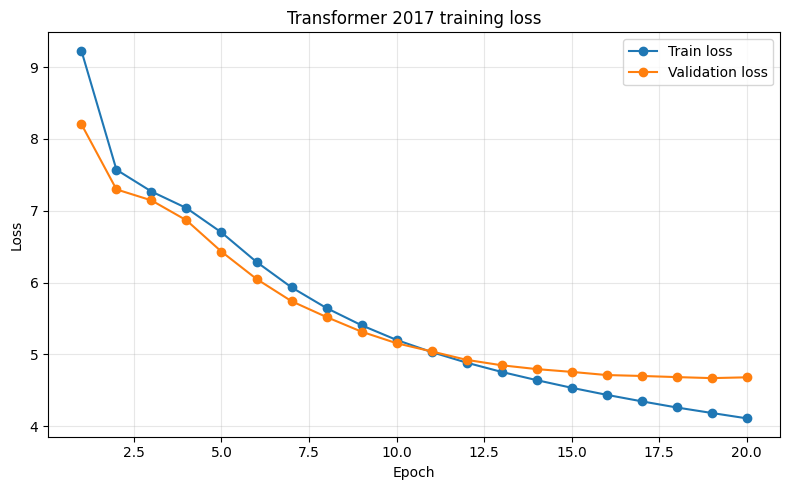

Loss curve saved to: /content/transformer_2017_vi_summarization/outputs/loss_curve.png


,epoch,train_loss,valid_loss,learning_rate,epoch_time_sec
0,1,9.227746,8.204805,0.000030,122.740149
1,2,7.570241,7.296559,0.000059,122.281009
2,3,7.267268,7.143575,0.000089,122.021271
3,4,7.036628,6.866230,0.000118,123.037138
4,5,6.696880,6.429784,0.000148,122.473132
5,6,6.286753,6.049686,0.000177,123.168007
6,7,5.932657,5.739974,0.000207,122.188517
7,8,5.644239,5.519203,0.000236,122.396458
8,9,5.404666,5.315316,0.000266,122.163077
9,10,5.200452,5.154686,0.000295,122.078813


In [18]:
import matplotlib.pyplot as plt

if len(history) == 0:
    raise ValueError('Chưa có history. Hãy chạy cell training trước khi vẽ biểu đồ loss.')

history_df = pd.DataFrame(history)
loss_curve_path = OUTPUT_DIR / 'loss_curve.png'

plt.figure(figsize=(8, 5))
plt.plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train loss')
plt.plot(history_df['epoch'], history_df['valid_loss'], marker='o', label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Transformer 2017 training loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(loss_curve_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Loss curve saved to: {loss_curve_path}')
display(history_df)


# 15. Sinh thử summary trên tập validation bằng greedy decoding

Cell này kiểm tra inference sau training trên một vài mẫu từ `valid_df` đã đọc từ `val.parquet`:

1. encode `article`;
2. bắt đầu decoder bằng token `<bos>`;
3. tại mỗi bước chọn token có logits cao nhất;
4. dừng khi gặp `<eos>` hoặc đạt `TGT_SEQ_LEN`;
5. decode IDs thành text.

Greedy decoding chỉ để kiểm tra nhanh mô hình sinh được chuỗi đầu ra. Cell kế tiếp sẽ tính ROUGE và BERTScore trên tập validation.


In [19]:
@torch.no_grad()
def greedy_decode(model: nn.Module, article: str, max_len: int = TGT_SEQ_LEN) -> str:
    model.eval()

    src = torch.tensor([encode_source(article, SRC_SEQ_LEN)], dtype=torch.long, device=device)
    src_mask = create_src_mask(src, pad_idx=PAD_IDX)
    encoder_output = model.encode(src, src_mask)

    ys = torch.tensor([[BOS_IDX]], dtype=torch.long, device=device)

    for _ in range(max_len - 1):
        tgt_mask = create_tgt_mask(ys, pad_idx=PAD_IDX)
        decoder_output = model.decode(encoder_output, src_mask, ys, tgt_mask)
        logits = model.project(decoder_output[:, -1:, :])
        next_token = torch.argmax(logits[:, -1, :], dim=-1).item()

        ys = torch.cat(
            [ys, torch.tensor([[next_token]], dtype=torch.long, device=device)],
            dim=1,
        )

        if next_token == EOS_IDX:
            break

    return decode_ids(ys.squeeze(0).tolist())


sample_count = min(3, len(valid_df))
for i in range(sample_count):
    sample = valid_df.iloc[i]
    print('=' * 100)
    print('ARTICLE:')
    print(str(sample['article'])[:1000], '...')
    print('\nGOLD SUMMARY:')
    print(sample['summary'])
    print('\nMODEL SUMMARY:')
    print(greedy_decode(model, sample['article']))


ARTICLE:
Giải thưởng công bố gần đây bởi World Travel Awards. Đây là năm thứ hai liên tiếp InterContinental Phu Quoc Long Beach Resort được vinh danh ở hạng mục gia đình trên toàn châu Á. Khu nghỉ dưỡng tọa lạc bên biển Phú Quốc, nổi bật với thiết kế lấy cảm hứng từ đại dương. Khuôn viên rộng rãi với nhiều mảng xanh thiên nhiên đậm chất nhiệt đới. Không gian sảnh lễ tân, phòng nghỉ, villa, nhà hàng... đều được chú trọng để tạo sự hài hòa với biển và cây cối. Du khách có thể chọn nghỉ ngơi tại khu phòng khách sạn rộng rãi, tiện nghi, hoặc những căn hộ, phòng suite, biệt thự cao cấp hướng biển. Mỗi không gian được thiết kế dựa trên tinh thần gắn kết các thành viên trong gia đình. Bên cạnh tiện nghi sang trọng, InterContinental Phu Quoc còn hút khách gia đình nhờ loạt trải nghiệm giải trí, thư giãn đa dạng, phù hợp với mọi độ tuổi. Với trẻ nhỏ, khu Planet Trekker là nơi các bé có thể thoải mái vui chơi, học hỏi từ các đầu sách thiếu nhi, những buổi workshop thủ công... Phụ huynh có thể yê

# 16. Đánh giá ROUGE và BERTScore trên tập validation

Cell này sinh summary cho các mẫu trong `valid_df` rồi tính các chỉ số đánh giá summarization:

- **ROUGE-1**: overlap unigram giữa prediction và reference.
- **ROUGE-2**: overlap bigram, phản ánh mức khớp cụm từ ngắn.
- **ROUGE-L**: dựa trên longest common subsequence, thường dùng cho summarization.
- **BERTScore Precision/Recall/F1**: so sánh embedding ngữ nghĩa giữa prediction và reference bằng mô hình đa ngôn ngữ.

Mặc định `METRIC_MAX_SAMPLES = None`, tức là đánh giá toàn bộ `val.parquet`. Nếu muốn chạy thử nhanh, đặt `METRIC_MAX_SAMPLES = 100` hoặc `200` ở cell cấu hình.

Kết quả được lưu vào:

```text
outputs/val_predictions.csv
outputs/val_metrics.json
```

BERTScore dùng pretrained multilingual encoder **chỉ để đánh giá**, không dùng trong kiến trúc Transformer from scratch.


In [22]:
%pip install -q bert-score sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.2 MB/s eta 0:00:00


In [23]:
import json
from rouge_score import rouge_scorer
from bert_score import score as bert_score
from sacrebleu import corpus_bleu


# ------------------------------------------------------------
# Cấu hình riêng cho các metric đánh giá validation
# ------------------------------------------------------------
# TOO_SHORT_MIN_TOKENS:
#   Nếu prediction có ít hơn số token này, coi là quá ngắn.
#   Ngưỡng 5 phù hợp để bắt các prediction kiểu "", ",,,", "và của".
TOO_SHORT_MIN_TOKENS = 5

# TOO_SHORT_REF_RATIO:
#   Nếu prediction ngắn hơn 50% độ dài reference, coi là quá ngắn.
#   Ví dụ reference dài 20 token nhưng prediction chỉ có 8 token thì bị đánh dấu too short.
TOO_SHORT_REF_RATIO = 0.5


@torch.no_grad()
def generate_predictions(dataframe: pd.DataFrame, max_samples: int | None = None) -> pd.DataFrame:
    """Sinh summary cho tập validation bằng greedy decoding.

    Hàm này chỉ dùng để đánh giá, không gọi backward và không cập nhật trọng số.

    Args:
        dataframe:
            DataFrame validation có 2 cột bắt buộc: article, summary.
        max_samples:
            Số mẫu validation tối đa dùng để đánh giá. Đặt None để dùng toàn bộ val.parquet.

    Returns:
        DataFrame gồm article, reference và prediction.
    """
    eval_df = dataframe.copy().reset_index(drop=True)
    if max_samples is not None:
        eval_df = eval_df.head(max_samples).reset_index(drop=True)
        print(f'[validation metrics] METRIC_MAX_SAMPLES enabled. Using {len(eval_df):,} rows.')

    predictions = []
    references = eval_df['summary'].astype(str).tolist()
    articles = eval_df['article'].astype(str).tolist()

    for idx, article in enumerate(articles, start=1):
        prediction = greedy_decode(model, article, max_len=TGT_SEQ_LEN)
        predictions.append(prediction)

        if idx == 1 or idx % 50 == 0 or idx == len(articles):
            print(f'Generated {idx}/{len(articles)} validation summaries')

    return pd.DataFrame({
        'article': articles,
        'reference': references,
        'prediction': predictions,
    })


def compute_rouge_scores(predictions: list[str], references: list[str]) -> dict:
    """Tính ROUGE-1, ROUGE-2 và ROUGE-L trung bình theo F1.

    ROUGE là bộ metric phổ biến nhất trong bài toán summarization.
    use_stemmer=False vì dữ liệu là tiếng Việt, stemmer tiếng Anh không phù hợp.
    """
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)
    totals = {'rouge1': 0.0, 'rouge2': 0.0, 'rougeL': 0.0}

    for pred, ref in zip(predictions, references):
        scores = scorer.score(ref, pred)
        for key in totals:
            totals[key] += scores[key].fmeasure

    n = max(1, len(predictions))
    return {key: value / n for key, value in totals.items()}


def compute_bertscore_scores(predictions: list[str], references: list[str]) -> dict:
    """Tính BERTScore P/R/F1 trung bình bằng mô hình đa ngôn ngữ.

    BERTScore bổ sung góc nhìn ngữ nghĩa cho ROUGE/BLEU vì không chỉ dựa trên trùng token.
    Lần chạy đầu tiên có thể mất thời gian do cần tải checkpoint của BERTSCORE_MODEL_TYPE.
    """
    if len(predictions) == 0:
        return {
            'bertscore_precision': 0.0,
            'bertscore_recall': 0.0,
            'bertscore_f1': 0.0,
        }

    bert_device = 'cuda' if torch.cuda.is_available() else 'cpu'
    precision, recall, f1 = bert_score(
        cands=predictions,
        refs=references,
        model_type=BERTSCORE_MODEL_TYPE,
        device=bert_device,
        batch_size=METRIC_BATCH_SIZE,
        verbose=True,
        rescale_with_baseline=False,
    )

    return {
        'bertscore_precision': float(precision.mean().item()),
        'bertscore_recall': float(recall.mean().item()),
        'bertscore_f1': float(f1.mean().item()),
    }


def compute_bleu_score(predictions: list[str], references: list[str]) -> dict:
    """Tính corpus BLEU bằng sacreBLEU.

    BLEU không phải metric tối ưu nhất cho summarization, nhưng vẫn là độ đo n-gram phổ biến.
    Ta dùng BLEU như metric phụ trong báo cáo, đi kèm ROUGE và BERTScore.
    """
    if len(predictions) == 0:
        return {'bleu': 0.0}

    bleu = corpus_bleu(
        predictions,
        [references],
        tokenize='intl',  # tokenizer quốc tế của sacreBLEU, chạy ổn với văn bản Unicode tiếng Việt.
    )
    return {'bleu': float(bleu.score)}  # sacreBLEU trả điểm theo thang 0-100.


def compute_too_short_rate(predictions: list[str], references: list[str]) -> dict:
    """Tính tỷ lệ summary sinh ra quá ngắn.

    Một prediction được xem là quá ngắn nếu thỏa ít nhất một trong hai điều kiện:
    1. Số token prediction < TOO_SHORT_MIN_TOKENS.
    2. Số token prediction < TOO_SHORT_REF_RATIO * số token reference.

    Metric này rất hữu ích với Transformer train from scratch vì model có thể bị collapse,
    sinh chuỗi quá ngắn hoặc chỉ gồm dấu câu/từ phổ biến.
    """
    if len(predictions) == 0:
        return {
            'avg_prediction_tokens': 0.0,
            'avg_reference_tokens': 0.0,
            'avg_length_ratio_pred_ref': 0.0,
            'empty_prediction_rate': 0.0,
            'too_short_rate': 0.0,
            'too_short_min_tokens': TOO_SHORT_MIN_TOKENS,
            'too_short_ref_ratio': TOO_SHORT_REF_RATIO,
        }

    pred_lengths = [len(tokenize(pred)) for pred in predictions]
    ref_lengths = [len(tokenize(ref)) for ref in references]

    empty_flags = [length == 0 for length in pred_lengths]
    too_short_flags = []
    length_ratios = []

    for pred_len, ref_len in zip(pred_lengths, ref_lengths):
        safe_ref_len = max(1, ref_len)
        length_ratio = pred_len / safe_ref_len
        length_ratios.append(length_ratio)

        is_too_short = (
            pred_len < TOO_SHORT_MIN_TOKENS
            or pred_len < TOO_SHORT_REF_RATIO * safe_ref_len
        )
        too_short_flags.append(is_too_short)

    n = len(predictions)
    return {
        'avg_prediction_tokens': float(sum(pred_lengths) / n),
        'avg_reference_tokens': float(sum(ref_lengths) / n),
        'avg_length_ratio_pred_ref': float(sum(length_ratios) / n),
        'empty_prediction_rate': float(sum(empty_flags) / n),
        'too_short_rate': float(sum(too_short_flags) / n),
        'too_short_min_tokens': TOO_SHORT_MIN_TOKENS,
        'too_short_ref_ratio': TOO_SHORT_REF_RATIO,
    }


# ------------------------------------------------------------
# Load checkpoint tốt nhất trước khi đánh giá validation cuối cùng
# ------------------------------------------------------------
if best_path.exists():
    checkpoint = torch.load(best_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    print(f'Loaded best checkpoint from epoch {checkpoint.get("epoch", "unknown")}: {best_path}')
else:
    print('Best checkpoint chưa tồn tại. Dùng model hiện tại để đánh giá.')
    model.eval()


# ------------------------------------------------------------
# Sinh prediction và tính toàn bộ metric trên val.parquet
# ------------------------------------------------------------
val_predictions_df = generate_predictions(valid_df, max_samples=METRIC_MAX_SAMPLES)

references = val_predictions_df['reference'].astype(str).tolist()
predictions = val_predictions_df['prediction'].astype(str).tolist()

rouge_metrics = compute_rouge_scores(predictions, references)
bertscore_metrics = compute_bertscore_scores(predictions, references)
bleu_metrics = compute_bleu_score(predictions, references)
length_metrics = compute_too_short_rate(predictions, references)

metrics = {
    'num_validation_samples': len(val_predictions_df),
    'decoding': 'greedy',
    'bert_score_model': BERTSCORE_MODEL_TYPE,
    **rouge_metrics,
    **bertscore_metrics,
    **bleu_metrics,
    **length_metrics,
}

predictions_path = OUTPUT_DIR / 'val_predictions.csv'
metrics_path = OUTPUT_DIR / 'val_metrics.json'

val_predictions_df.to_csv(predictions_path, index=False)
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print('Validation metrics:')
print(json.dumps(metrics, ensure_ascii=False, indent=2))
print(f'Predictions saved to: {predictions_path}')
print(f'Metrics saved to: {metrics_path}')

display(val_predictions_df.head(10)[['reference', 'prediction']])

Loaded best checkpoint from epoch 19: /content/transformer_2017_vi_summarization/outputs/checkpoints/transformer_2017_best.pt
Generated 1/1349 validation summaries
Generated 50/1349 validation summaries
Generated 100/1349 validation summaries
Generated 150/1349 validation summaries
Generated 200/1349 validation summaries
Generated 250/1349 validation summaries
Generated 300/1349 validation summaries
Generated 350/1349 validation summaries
Generated 400/1349 validation summaries
Generated 450/1349 validation summaries
Generated 500/1349 validation summaries
Generated 550/1349 validation summaries
Generated 600/1349 validation summaries
Generated 650/1349 validation summaries
Generated 700/1349 validation summaries
Generated 750/1349 validation summaries
Generated 800/1349 validation summaries
Generated 850/1349 validation summaries
Generated 900/1349 validation summaries
Generated 950/1349 validation summaries
Generated 1000/1349 validation summaries
Generated 1050/1349 validation summa

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

...

computing greedy matching.


  0%|          | 0/169 [00:00<?, ?it/s]

done in 6.54 seconds, 206.32 sentences/sec


Validation metrics:
{
  "num_validation_samples": 1349,
  "decoding": "greedy",
  "bert_score_model": "xlm-roberta-base",
  "rouge1": 0.49118036825847927,
  "rouge2": 0.15741898578969266,
  "rougeL": 0.2753137332333104,
  "bertscore_precision": 0.8190804719924927,
  "bertscore_recall": 0.8202314376831055,
  "bertscore_f1": 0.8194103837013245,
  "bleu": 2.325046671258375,
  "avg_prediction_tokens": 119.3461823573017,
  "avg_reference_tokens": 114.69236471460341,
  "avg_length_ratio_pred_ref": 1.085137588857481,
  "empty_prediction_rate": 0.0,
  "too_short_rate": 0.0037064492216456633,
  "too_short_min_tokens": 5,
  "too_short_ref_ratio": 0.5
}
Predictions saved to: /content/transformer_2017_vi_summarization/outputs/val_predictions.csv
Metrics saved to: /content/transformer_2017_vi_summarization/outputs/val_metrics.json


,reference,prediction
0,InterContinental Phu Quoc Long Beach Resort đã...,"lễ hội "" du lịch "" tại tp hcm đã diễn ra tại s..."
1,Việt Nam đã xếp hạng 15 trên bảng xếp hạng 20 ...,việt nam là một trong những điểm đến đến đến đ...
2,"Ngày hội Văn hóa, Thể thao và Du lịch các dân ...",hội thảo về văn hóa văn hóa việt nam tại hội n...
3,"Phú Quốc, đảo ngọc của Việt Nam, đã được vinh ...",lễ hội du lịch quốc gia việt nam 2024 diễn ra ...
4,KKday Vietnam vừa công bố hợp tác chiến lược v...,"tại hội thảo quốc tế <unk> , hội thảo giới thi..."
5,Công ty du lịch Nhật Bản AZ tung ra các tour d...,"ngày hội du lịch việt nam tại hà nội , hà nội ..."
6,"Chùa Phổ Quang, một công trình kiến trúc được ...",cầu đường sắt <unk> <unk> ở huyện thanh sơn đư...
7,Bài viết giới thiệu hai điểm đến nghỉ dưỡng lý...,một du khách việt nam tại một khu du lịch nổi ...
8,Tour liên tuyến Hàn Quốc - Nhật Bản (7-8 ngày)...,chuyến thăm việt nam lần thứ hai tại việt nam ...
9,Bảo tàng thịt nướng (Museum of BQQ) sẽ mở cửa ...,"hội thảo "" the best the the the the the the th..."


# 18. Đánh giá trên tập test cuối kỳ

Phần này được chuẩn bị sẵn cho ngày thầy cung cấp `test.parquet`.  
Mặc định `RUN_TEST_EVALUATION = False`, nên các cell bên dưới **không làm gì** nếu chưa có tập test.

Khi nhận được tập test:

1. Đặt file vào `DATA_DIR`, ví dụ:

```text
/content/transformer_2017_vi_summarization/data/test.parquet
```

2. Đổi trong cell cấu hình:

```python
RUN_TEST_EVALUATION = True
```

3. Chạy lại phần này. Notebook sẽ:

- load checkpoint tốt nhất `transformer_2017_best.pt`;
- đọc `test.parquet`;
- sinh summary cho từng `article`;
- lưu `test_predictions.csv`;
- nếu test có cột `summary`, tính thêm ROUGE và BERTScore rồi lưu `test_metrics.json`.

Lưu ý: không dùng test để train, không build vocabulary từ test, không chỉnh tham số dựa trên test. Test chỉ dùng cho đánh giá cuối cùng.


In [ ]:
# ================================================================
# Code dự phòng cho tập test cuối kỳ
# ================================================================
# Cell này được viết để an toàn khi chưa có test.parquet:
# - Nếu RUN_TEST_EVALUATION = False: chỉ in hướng dẫn và bỏ qua.
# - Nếu RUN_TEST_EVALUATION = True: đọc test.parquet, sinh prediction,
#   và tính metric nếu test có cột summary.


def test_file_exists() -> bool:
    """Kiểm tra test.parquet có tồn tại trong các thư mục mà notebook hỗ trợ hay chưa."""
    try:
        _ = find_data_path(TEST_FILENAME)
        return True
    except FileNotFoundError:
        return False


def clean_test_dataframe(dataframe: pd.DataFrame, name: str = 'test') -> tuple[pd.DataFrame, bool]:
    """Làm sạch tập test.

    Tập test cuối kỳ có thể có 2 dạng:
    1. Có article và summary: dùng để sinh prediction + tính metric.
    2. Chỉ có article: dùng để sinh prediction nộp/chấm ngoài.

    Hàm trả về:
    - dataframe đã làm sạch;
    - has_reference = True nếu có cột summary hợp lệ.
    """
    if TEST_ARTICLE_COL not in dataframe.columns:
        raise ValueError(
            f'[{name}] Dataset thiếu cột {TEST_ARTICLE_COL!r}. '
            f'Các cột hiện có: {list(dataframe.columns)}'
        )

    has_reference = TEST_SUMMARY_COL in dataframe.columns

    keep_cols = [TEST_ARTICLE_COL]
    if has_reference:
        keep_cols.append(TEST_SUMMARY_COL)

    dataframe = dataframe[keep_cols].copy()
    dataframe = dataframe.dropna(subset=[TEST_ARTICLE_COL])
    dataframe = dataframe[dataframe[TEST_ARTICLE_COL].astype(str).str.strip().ne('')]

    if has_reference:
        dataframe = dataframe.dropna(subset=[TEST_SUMMARY_COL])
        dataframe = dataframe[dataframe[TEST_SUMMARY_COL].astype(str).str.strip().ne('')]

    dataframe = dataframe.drop_duplicates().reset_index(drop=True)

    print(f'[{name}] Rows after cleaning: {len(dataframe):,}')
    print(f'[{name}] Has reference summary:', has_reference)
    return dataframe, has_reference


@torch.no_grad()
def generate_test_predictions(dataframe: pd.DataFrame, max_samples: int | None = None) -> pd.DataFrame:
    """Sinh summary cho tập test bằng mô hình Transformer 2017 đã train.

    Hàm này chỉ dùng để inference/evaluation, không gọi backward, không cập nhật trọng số.
    """
    eval_df = dataframe.copy().reset_index(drop=True)
    if max_samples is not None:
        eval_df = eval_df.head(max_samples).reset_index(drop=True)
        print(f'[test] TEST_MAX_SAMPLES enabled. Using {len(eval_df):,} rows.')

    articles = eval_df[TEST_ARTICLE_COL].astype(str).tolist()
    predictions = []

    for idx, article in enumerate(articles, start=1):
        pred = greedy_decode(model, article, max_len=TGT_SEQ_LEN)
        predictions.append(pred)

        if idx == 1 or idx % 50 == 0 or idx == len(articles):
            print(f'Generated {idx}/{len(articles)} test summaries')

    result_df = pd.DataFrame({
        TEST_ARTICLE_COL: articles,
        'prediction': predictions,
    })

    if TEST_SUMMARY_COL in eval_df.columns:
        result_df['reference'] = eval_df[TEST_SUMMARY_COL].astype(str).tolist()

    return result_df


In [ ]:
# ================================================================
# Chạy đánh giá test khi đã có test.parquet
# ================================================================
# Để kích hoạt phần này:
# 1. Upload test.parquet vào DATA_DIR.
# 2. Đổi RUN_TEST_EVALUATION = True ở cell cấu hình.
# 3. Chạy cell này.

if not RUN_TEST_EVALUATION:
    print('RUN_TEST_EVALUATION = False, bỏ qua phần test.')
    print('Khi nhận được test.parquet, hãy đặt file vào DATA_DIR và đổi RUN_TEST_EVALUATION = True.')
else:
    if not test_file_exists():
        raise FileNotFoundError(
            f'RUN_TEST_EVALUATION = True nhưng chưa tìm thấy {TEST_FILENAME}. '
            f'Hãy đặt file vào {DATA_DIR} hoặc /content/data.'
        )

    # Luôn load checkpoint tốt nhất trước khi đánh giá test.
    # Như vậy kết quả test dùng model có validation loss tốt nhất, không phải epoch cuối.
    if best_path.exists():
        checkpoint = torch.load(best_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.to(device)
        model.eval()
        print(f'Loaded best checkpoint from epoch {checkpoint.get("epoch", "unknown")}: {best_path}')
    else:
        print('Cảnh báo: chưa tìm thấy best checkpoint. Dùng model hiện tại trong RAM để sinh test predictions.')
        model.eval()

    raw_test_df = read_parquet_safely(TEST_FILENAME, name='test')
    test_df, test_has_reference = clean_test_dataframe(raw_test_df, name='test')

    test_predictions_df = generate_test_predictions(test_df, max_samples=TEST_MAX_SAMPLES)

    test_predictions_path = OUTPUT_DIR / 'test_predictions.csv'
    test_predictions_df.to_csv(test_predictions_path, index=False)
    print(f'Test predictions saved to: {test_predictions_path}')

    # Nếu test.parquet có summary thì tính metric giống validation.
    if test_has_reference:
        test_references = test_predictions_df['reference'].astype(str).tolist()
        test_predictions = test_predictions_df['prediction'].astype(str).tolist()

        test_rouge_metrics = compute_rouge_scores(test_predictions, test_references)
        test_bertscore_metrics = compute_bertscore_scores(test_predictions, test_references)

        test_metrics = {
            'num_test_samples': len(test_predictions_df),
            'decoding': 'greedy',
            'bert_score_model': BERTSCORE_MODEL_TYPE,
            **test_rouge_metrics,
            **test_bertscore_metrics,
        }

        test_metrics_path = OUTPUT_DIR / 'test_metrics.json'
        with open(test_metrics_path, 'w', encoding='utf-8') as f:
            json.dump(test_metrics, f, ensure_ascii=False, indent=2)

        print('Test metrics:')
        print(json.dumps(test_metrics, ensure_ascii=False, indent=2))
        print(f'Test metrics saved to: {test_metrics_path}')

        display(test_predictions_df[[TEST_ARTICLE_COL, 'reference', 'prediction']].head(10))
    else:
        print('test.parquet không có cột summary nên không tính ROUGE/BERTScore.')
        print('Chỉ lưu prediction để nộp hoặc chấm bằng hệ thống ngoài.')
        display(test_predictions_df[[TEST_ARTICLE_COL, 'prediction']].head(10))


# 19. Gợi ý thao tác khi nhận tập test

Khi thầy cung cấp `test.parquet`, không sửa lại kiến trúc hoặc training loop. Chỉ làm đúng các bước sau:

1. Upload `test.parquet` vào thư mục `data/`.
2. Kiểm tra tên file đúng là `test.parquet`; nếu tên khác, sửa `TEST_FILENAME` trong cell cấu hình.
3. Đổi `RUN_TEST_EVALUATION = True`.
4. Nếu runtime vẫn còn model/checkpoint sau training, chạy từ phần **18. Đánh giá trên tập test cuối kỳ** trở xuống.
5. Nếu runtime đã mất, chạy lại notebook từ đầu để khôi phục environment và load checkpoint.
6. Lấy file `outputs/test_predictions.csv` để nộp hoặc đưa vào báo cáo.
7. Nếu có `outputs/test_metrics.json`, dùng các chỉ số ROUGE/BERTScore trong báo cáo cuối.

Không nên train lại trên test, không build vocabulary từ test, và không chọn checkpoint dựa trên test. Test chỉ dùng một lần để đánh giá cuối cùng.


# 20. Gợi ý mô tả kết quả trong báo cáo

Khi viết báo cáo, có thể mô tả notebook như sau:

- Mô hình Transformer encoder-decoder được tự cài đặt bằng PyTorch, không dùng `nn.Transformer`.
- Kiến trúc bám sát Transformer 2017: sinusoidal positional encoding, multi-head attention chuẩn, feed-forward ReLU, post-norm Add & Norm, dropout và Xavier initialization.
- Dữ liệu `article → summary` được đưa vào encoder-decoder theo đúng bài toán sequence-to-sequence.
- Decoder nhận `summary` đã dịch phải bằng token `<bos>` và học dự đoán token tiếp theo.
- Loss được tính bằng CrossEntropyLoss, bỏ qua padding và dùng label smoothing `0.1` như paper.
- Optimizer dùng Adam với `β1 = 0.9`, `β2 = 0.98`, `eps = 1e-9` và learning-rate schedule có warmup theo Transformer 2017.
- Validation được đọc từ file `val.parquet` riêng, không chia từ tập train.
- Biểu đồ loss được vẽ để quan sát quá trình học qua từng epoch.
- Sau training, mô hình được đánh giá trên tập validation bằng ROUGE-1, ROUGE-2, ROUGE-L và BERTScore.

Nếu kết quả tóm tắt chưa tốt, cần nhấn mạnh rằng mô hình được train từ đầu trên dataset nhỏ nên chủ yếu dùng để minh họa kiến trúc và pipeline huấn luyện, không thể so sánh trực tiếp với các mô hình pretrained như ViT5/BARTPho.
